# Quantum Protein Folding Simulation Circuit Template

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import numpy as np
import matplotlib.pyplot as plt

## Tetrahedral Lattice Structure

Proteins are folded on a **3D tetrahedral (diamond) lattice**. Every lattice site has exactly 4 nearest neighbours, each reached by one of the four tetrahedral bond vectors below. The lattice is bipartite (type-A / type-B sublattices), so consecutive residues alternate between stepping by **+v_i** and **−v_i**, keeping all bond angles at the tetrahedral angle of 109.47°.

| Axis | Bond vector | Dense encoding (q₁, q₂) |
|------|-------------|--------------------------|
| 0    | v₀ = (+1,+1,+1)/√3 | (0, 0) |
| 1    | v₁ = (+1,−1,−1)/√3 | (0, 1) |
| 2    | v₂ = (−1,+1,−1)/√3 | (1, 0) |
| 3    | v₃ = (−1,−1,+1)/√3 | (1, 1) |

Run the cell below to render the lattice diagram.

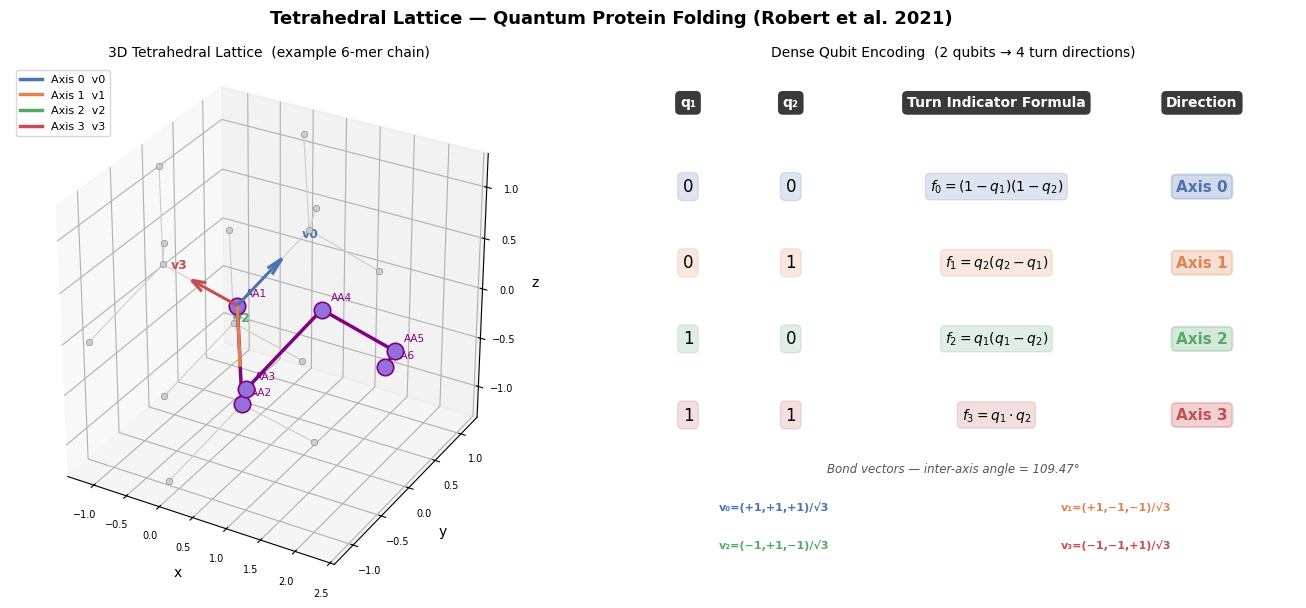

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

DIRS = np.array([
    [ 1,  1,  1],
    [ 1, -1, -1],
    [-1,  1, -1],
    [-1, -1,  1],
], dtype=float) / np.sqrt(3)
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig = plt.figure(figsize=(14, 6))
fig.suptitle('Tetrahedral Lattice — Quantum Protein Folding (Robert et al. 2021)',
             fontsize=13, fontweight='bold')

# ── Left: 3D lattice ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_title('3D Tetrahedral Lattice  (example 6-mer chain)', fontsize=10)
origin = np.zeros(3)

first_shell = [origin + DIRS[i] for i in range(4)]
edges = [(origin, nb) for nb in first_shell]
second_shell = []
for nb in first_shell:
    for j in range(4):
        s2 = nb - DIRS[j]
        if not np.allclose(s2, origin):
            second_shell.append(s2)
            edges.append((nb, s2))

for p1, p2 in edges:
    ax1.plot(*zip(p1, p2), color='#cccccc', linewidth=0.8, zorder=1)
for node in [origin] + first_shell + second_shell:
    ax1.scatter(*node, color='#cccccc', s=22, zorder=2,
                edgecolors='gray', linewidths=0.4)

for i, (d, color) in enumerate(zip(DIRS, COLORS)):
    ax1.quiver(*origin, *(d * 0.62), color=color, linewidth=2.2,
               arrow_length_ratio=0.28, zorder=6)
    ax1.text(*(origin + d * 0.9), f'v{i}', fontsize=9,
             color=color, fontweight='bold', zorder=7)
ax1.scatter(*origin, color='black', s=100, zorder=8)

# 6-mer example chain
chain_axes = [1, 2, 0, 3, 2]
chain_pos = [origin.copy()]
pos = origin.copy()
for step, ax_idx in enumerate(chain_axes):
    pos = pos + (DIRS[ax_idx] if step % 2 == 0 else -DIRS[ax_idx])
    chain_pos.append(pos.copy())
chain_pos = np.array(chain_pos)
ax1.plot(chain_pos[:, 0], chain_pos[:, 1], chain_pos[:, 2],
         color='purple', linewidth=2.5, zorder=9)
for k, cp in enumerate(chain_pos):
    ax1.scatter(*cp, color='mediumpurple', s=140, zorder=10,
                edgecolors='purple', linewidths=1.2)
    ax1.text(cp[0]+0.07, cp[1]+0.07, cp[2]+0.07, f'AA{k+1}',
             fontsize=7.5, color='purple', zorder=11)

ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')
ax1.tick_params(labelsize=7)
ax1.set_box_aspect([1, 1, 1])
ax1.legend(handles=[Line2D([0],[0], color=c, linewidth=2.5, label=f'Axis {i}  v{i}')
                    for i, c in enumerate(COLORS)],
           loc='upper left', fontsize=8, framealpha=0.75)

# ── Right: encoding table ─────────────────────────────────────────────────
ax2 = fig.add_subplot(122)
ax2.set_title('Dense Qubit Encoding  (2 qubits → 4 turn directions)', fontsize=10)
ax2.set_xlim(0, 4); ax2.set_ylim(-1.0, 5.8); ax2.axis('off')

col_x = [0.45, 1.05, 2.25, 3.45]
for hdr, x in zip(['q₁', 'q₂', 'Turn Indicator Formula', 'Direction'], col_x):
    ax2.text(x, 5.3, hdr, ha='center', va='center', fontsize=10,
             fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='#3a3a3a', edgecolor='none'))

rows = [
    ('0','0', r'$f_0=(1-q_1)(1-q_2)$',  'Axis 0', COLORS[0]),
    ('0','1', r'$f_1=q_2(q_2-q_1)$',    'Axis 1', COLORS[1]),
    ('1','0', r'$f_2=q_1(q_1-q_2)$',    'Axis 2', COLORS[2]),
    ('1','1', r'$f_3=q_1 \cdot q_2$',   'Axis 3', COLORS[3]),
]
for (q1, q2, formula, direction, color), ry in zip(rows, [4.2, 3.2, 2.2, 1.2]):
    bg = dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.18,
              edgecolor=color, linewidth=1)
    ax2.text(col_x[0], ry, q1,        ha='center', va='center', fontsize=12, bbox=bg)
    ax2.text(col_x[1], ry, q2,        ha='center', va='center', fontsize=12, bbox=bg)
    ax2.text(col_x[2], ry, formula,   ha='center', va='center', fontsize=10, bbox=bg)
    ax2.text(col_x[3], ry, direction, ha='center', va='center', fontsize=11,
             fontweight='bold', color=color,
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                       alpha=0.25, edgecolor=color, linewidth=1.5))

ax2.text(2.0, 0.45, 'Bond vectors — inter-axis angle = 109.47°',
         ha='center', fontsize=8.5, color='#555', style='italic')
for vs, color, (px, py) in zip(
    ['v₀=(+1,+1,+1)/√3','v₁=(+1,−1,−1)/√3','v₂=(−1,+1,−1)/√3','v₃=(−1,−1,+1)/√3'],
    COLORS,
    [(0.95,-0.05),(2.95,-0.05),(0.95,-0.55),(2.95,-0.55)]
):
    ax2.text(px, py, vs, ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

## Circuit Construction Function

In [3]:
def build_protein_folding_ansatz(num_amino_acids: int, 
                                 encoding: str = "dense", 
                                 num_interaction_qubits: int = 1, 
                                 depth: int = 2, 
                                 entangling_type: str = "closed_loop") -> QuantumCircuit:
    """
    Constructs the parameterized variational circuit for protein folding.
    
    Args:
        num_amino_acids: Total length of the protein sequence (N).
        encoding: "dense" (2 qubits per turn) or "sparse" (4 qubits per turn).
        num_interaction_qubits: Number of auxiliary qubits tracking physical contacts.
        depth: Number of repetitions of the entangling and rotation blocks (m).
        entangling_type: "closed_loop" (linear with feedback) or "all_to_all".
        
    Returns:
        A parameterized Qiskit QuantumCircuit.
    """
    # 1. Determine configuration qubits (N_cf)
    if encoding == "dense":
        # Dense encoding uses 2 qubits per active turn.
        # First 2 turns are pinned to eliminate rotational symmetry.
        num_config_qubits = 2 * (num_amino_acids - 3)
    elif encoding == "sparse":
        # Sparse encoding uses 4 qubits per active turn (one-hot).
        num_config_qubits = 4 * (num_amino_acids - 3)
    else:
        raise ValueError("Encoding must be either 'dense' or 'sparse'.")
        
    # Total qubits (n = N_cf + N_in)
    total_qubits = num_config_qubits + num_interaction_qubits
    
    # Initialize the circuit
    qc = QuantumCircuit(total_qubits)
    
    # Create the parameterized vector for the classical optimizer
    # Number of parameters = total_qubits * (depth + 1)
    num_params = total_qubits * (depth + 1)
    theta = ParameterVector('\u03b8', num_params)
    param_idx = 0
    
    # --- STEP A: INITIALIZATION LAYER ---
    # Apply Hadamard gates to create an equal superposition of all states
    for qubit in range(total_qubits):
        qc.h(qubit)
        
    # Apply the first layer of parameterized RY rotations
    for qubit in range(total_qubits):
        qc.ry(theta[param_idx], qubit)
        param_idx += 1
        
    qc.barrier()
    
    # --- STEP B: REPETITIVE ENTANGLING AND ROTATION BLOCKS ---
    for d in range(depth):
        # 1. Entangling Layer
        if entangling_type == "closed_loop":
            # Linear entangling chain with loopback (ideal for NISQ hardware layout)
            for qubit in range(total_qubits - 1):
                qc.cx(qubit, qubit + 1)
            if total_qubits > 2:
                # Loopback CNOT from last qubit to the first
                qc.cx(total_qubits - 1, 0)
                
        elif entangling_type == "all_to_all":
            # All-to-all entangling pairs
            for i in range(total_qubits):
                for j in range(i + 1, total_qubits):
                    qc.cx(i, j)
        else:
            raise ValueError("Entangling type must be \'closed_loop\' or \'all_to_all\'.")
            
        qc.barrier()
        
        # 2. Parameterized Rotation Layer
        for qubit in range(total_qubits):
            qc.ry(theta[param_idx], qubit)
            param_idx += 1
            
        qc.barrier()
        
    # --- STEP C: MEASUREMENT SETUP ---
    # In VQE, we measure all qubits in the computational (Z) basis
    qc.measure_all()
    
    return qc

## Classical Helper: Turn Indicator Evaluation

In [4]:
def evaluate_dense_turn_indicators(qubit_string: str, turn_idx: int):
    """
    Classical helper to calculate the dense turn indicators for a given measured bitstring.
    Turn i corresponds to qubit register bits (q_{2i-1}, q_{2i}).
    
    The formulas are:
        f_0 = (1-q1)(1-q2)  [Axis 0]
        f_1 = q2(q2 - q1)   [Axis 1]
        f_2 = q1(q1 - q2)   [Axis 2]
        f_3 = q1*q2         [Axis 3]
    """
    # Bitstrings in Qiskit are read right-to-left. 
    # Extract the two bits representing the given turn index (1-based index)
    # We map 1-based turn_idx to corresponding qubit offsets
    offset = 2 * (turn_idx - 1)
    
    # Extract bits (reversing because of Qiskit\'s MSB-first ordering)
    reversed_bits = qubit_string[::-1]
    q1 = int(reversed_bits[offset])
    q2 = int(reversed_bits[offset + 1])
    
    # Evaluate indicator outputs
    f0 = (1 - q1) * (1 - q2)
    f1 = q2 * (q2 - q1)
    f2 = q1 * (q1 - q2)
    f3 = q1 * q2
    
    return {0: f0, 1: f1, 2: f2, 3: f3}

## Example: 7-Amino-Acid Peptide Setup

In [5]:
# Example setup for a 7-amino-acid peptide
N = 7  
print(f"Setting up simulation parameters for a protein of length N = {N}...")

# Configuration qubits under dense encoding = 2 * (N - 3) = 8 qubits
# Interaction qubits tracking contacts = 1 qubit (APRL-RFY example)
N_cf = 2 * (N - 3)
N_in = 1
total_qubits = N_cf + N_in

print(f"Configuration Qubits (N_cf): {N_cf}")
print(f"Interaction Qubits (N_in)  : {N_in}")
print(f"Total Qubits in Register   : {total_qubits}")

Setting up simulation parameters for a protein of length N = 7...
Configuration Qubits (N_cf): 8
Interaction Qubits (N_in)  : 1
Total Qubits in Register   : 9


## Build the Ansatz Circuit

In [6]:
# Build circuit with NISQ-friendly closed-loop CNOTs and depth = 2
ansatz = build_protein_folding_ansatz(
    num_amino_acids=N,
    encoding="dense",
    num_interaction_qubits=N_in,
    depth=2,
    entangling_type="closed_loop"
)

print("--- Circuit Summary ---")
print(f"Number of Parameters (\u03b8): {ansatz.num_parameters}")
print(f"Number of Gates         : {dict(ansatz.count_ops())}")
print(f"Circuit Depth           : {ansatz.depth()}")

--- Circuit Summary ---
Number of Parameters (θ): 27
Number of Gates         : {'ry': 27, 'cx': 18, 'h': 9, 'measure': 9, 'barrier': 6}
Circuit Depth           : 23


## Draw the Circuit

Draft Circuit Diagram Structure:


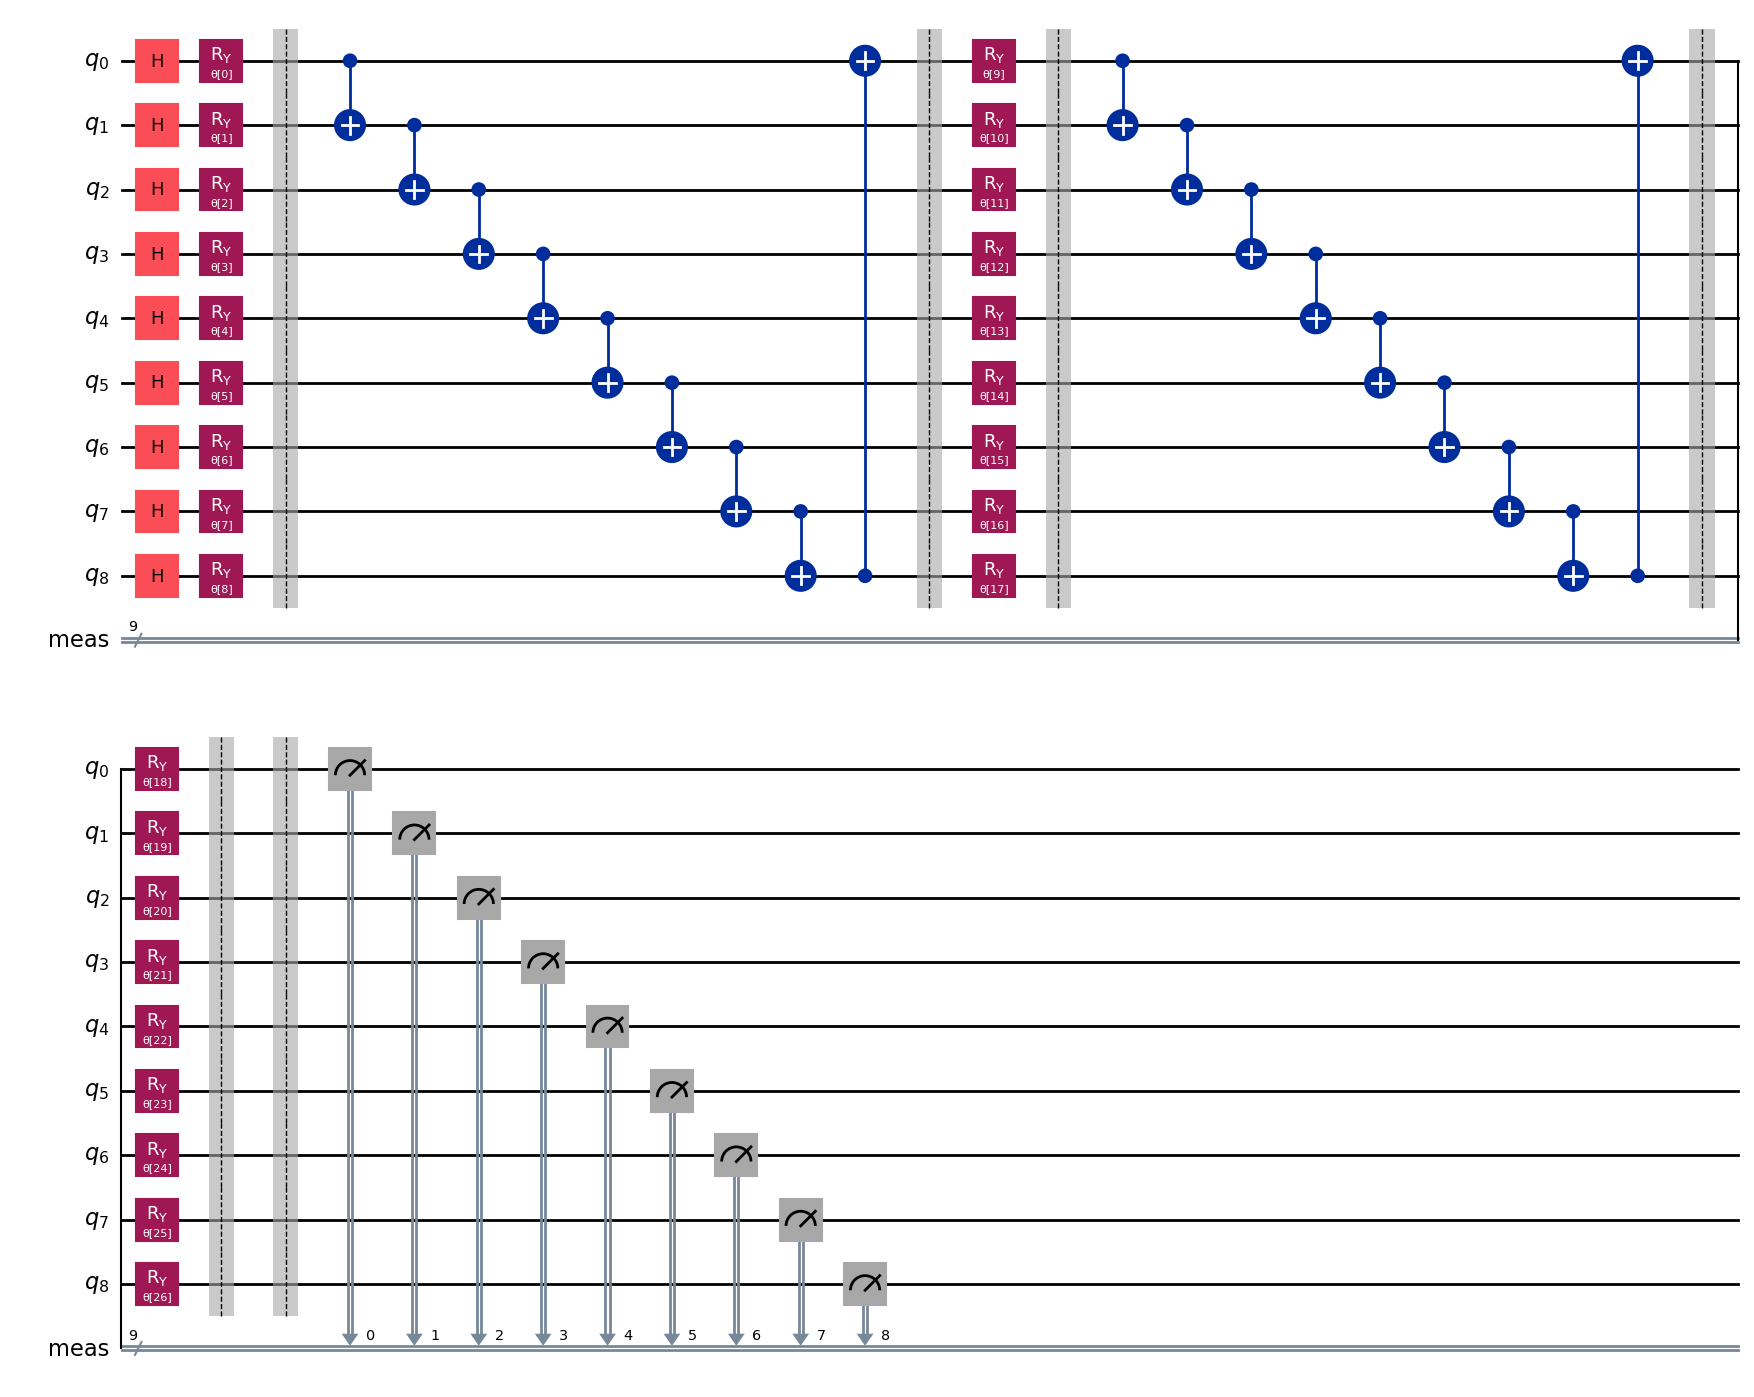

In [7]:
print("Draft Circuit Diagram Structure:")
fig = ansatz.draw(output='mpl')
fig

## Mock Bitstring Evaluation

In [8]:
# Mock analysis of a measured bitstring
# e.g., a measurement result of 9 qubits: "010011000"
mock_measurement = "010011000"
print("--- Mock Bitstring Evaluation ---")
print(f"Let\'s evaluate a sample measurement string: \'{mock_measurement}\'")
print("Evaluating Turn 1 directions (represented by first two configuration qubits):")
indicators = evaluate_dense_turn_indicators(mock_measurement, turn_idx=1)
for axis, state in indicators.items():
    print(f"  Turn Indicator f_{axis}(1) = {state}")

--- Mock Bitstring Evaluation ---
Let's evaluate a sample measurement string: '010011000'
Evaluating Turn 1 directions (represented by first two configuration qubits):
  Turn Indicator f_0(1) = 1
  Turn Indicator f_1(1) = 0
  Turn Indicator f_2(1) = 0
  Turn Indicator f_3(1) = 0
